In [3]:
import pandas as pd
import matplotlib.pyplot as plt   # library for creating charts/graphs
import seaborn as sns              # library built on matplotlib, makes prettier charts
custom_palette =['#E50914', '#221f1f', '#141414', '#B20710']

['#221f1f', '#b20710', '#e50914','#f5f5f1']

# Set the custom palette
sns.set_palette(custom_palette)
netflix = pd.read_csv("netflix_cleaned.csv")  # load = read the file into memory
netflix.head()

,show_id,type,title,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# Step 1: Extract and clean country information

In [4]:

# Split each row's countries into a list, then "explode" (expand) into separate rows
df_country = netflix.assign(country=netflix['country'].str.split(', ')).explode('country')

df_country['country'] = df_country['country'].str.strip()   # remove extra spaces

In [10]:
df_country['country']

0       United States
1        South Africa
2             Unknown
3             Unknown
4               India
            ...      
8789    United States
8790          Unknown
8791    United States
8792    United States
8793            India
Name: country, Length: 10832, dtype: object

 # Step 2: Calculate content count by country

In [5]:
country_counts = df_country['country'].value_counts()

# Remove Unknown once, so it does not affect our visulisation  
country_counts = country_counts.drop('Unknown', errors='ignore')
print(country_counts)
#Content count = the number of titles (Movies + TV Shows) associated with each country.

country
United States     3680
India             1046
United Kingdom     803
Canada             445
France             393
                  ... 
Bermuda              1
Ecuador              1
Armenia              1
Mongolia             1
Montenegro           1
Name: count, Length: 127, dtype: int64


# Step 3: Identify top content-producing countries

In [7]:
top_countries = country_counts.head(10)   # top 10 countries by content count
print(top_countries)

country
United States     3680
India             1046
United Kingdom     803
Canada             445
France             393
Japan              317
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64


# Step 4: Create charts and rankings

C:\Users\Manmohan\AppData\Local\Temp\ipykernel_5404\3877039577.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette=custom_palette )
C:\Users\Manmohan\AppData\Local\Temp\ipykernel_5404\3877039577.py:2: UserWarning: 
The palette list has fewer values (4) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x=top_countries.values, y=top_countries.index, palette=custom_palette )


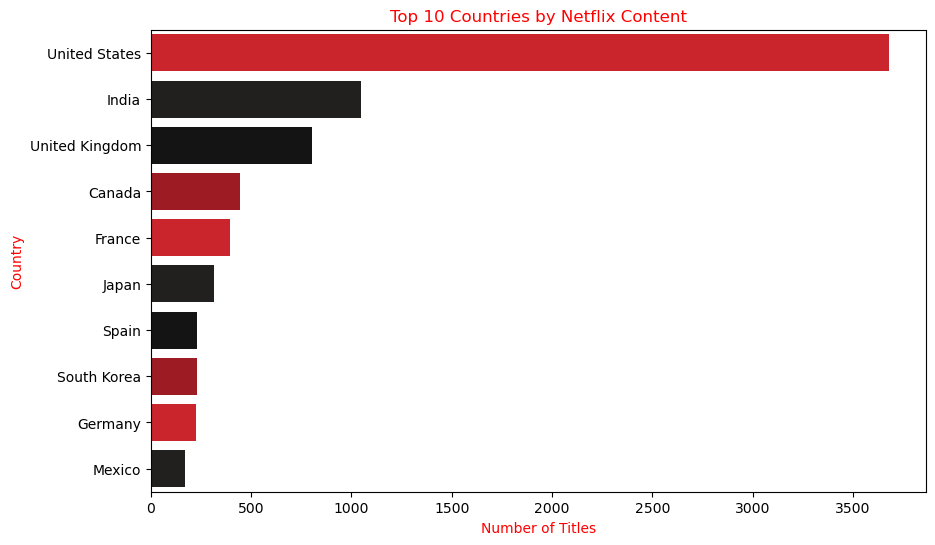

In [8]:

plt.figure(figsize=(10,6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette=custom_palette )
plt.title("Top 10 Countries by Netflix Content" , color= 'red')
plt.xlabel("Number of Titles" ,color='red')
plt.ylabel("Country" ,color = 'red')
plt.show()

# ✅The United States, India, and the United Kingdom are the top three countries contributing the most content to Netflix 🥇🇺🇸🥈🇮🇳🥉UK

C:\Users\Manmohan\AppData\Local\Temp\ipykernel_5404\4098817919.py:6: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.countplot(data=df_top, y='country', hue='type', order=top10_list, palette=custom_palette)


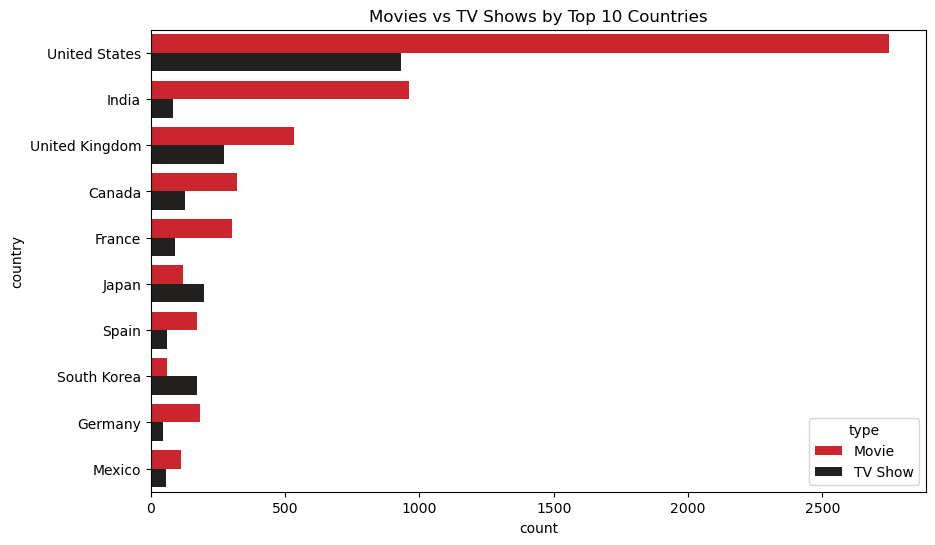

In [9]:
top10_list = top_countries.index.tolist()
# isin() = checks whether each value is in a given list — used here to filter to only the top 10 countries.
df_top = df_country[df_country['country'].isin(top10_list)]
plt.figure(figsize=(10,6))
#hue = a parameter in seaborn that splits/colors bars by a second category (here, Movie vs TV Show).
sns.countplot(data=df_top, y='country', hue='type', order=top10_list, palette=custom_palette)
plt.title("Movies vs TV Shows by Top 10 Countries")
plt.show()

In [23]:
top_country = country_counts.idxmax()   # idxmax = returns the index (label) with the highest value
top_count = country_counts.max()

print(f"{top_country} produces the most Netflix content with {top_count} titles.")
print(f"Top 5 countries account for {top_countries.head(5).sum()} titles out of {country_counts.sum()} total entries.")

United States produces the most Netflix content with 3680 titles.
Top 5 countries account for 6367 titles out of 10002 total entries.


# business insights
1) The United States and India are usually the top two content-producing countries.
2) A small number of countries (top 5–10) often account for the majority (more than half) of all Netflix content — showing content is         concentrated (focused heavily) in a few markets rather than evenly spread globally.
3) Countries such as Japan and South Korea have substantial representation, demonstrating growing demand for anime, K-dramas, and Asian       entertainment.
4) Netflix has a diverse global catalog, with content originating from many countries rather than a single region.
